In [1]:
%reload_ext autoreload
%autoreload 2

import pickle
import numpy as np
import healpy as hp
import json
from scipy import interpolate

import sys
sys.path.append("..")

from utils.validation import roc_finite_sample_band

from utils.multi_corner import multi_corner

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file("../../nptf-test/production/matplotlibrc")

# Coverage

In [ ]:
run_name = 'hmc_Dbase23fix_deltapsf_2_Mbase23fix_1exp_deltapsf'
# z = pickle.load(open(f'/n/holylabs/LABS/iaifi_lab/Users/yitians/fermi/fermi-prob-prog/outputs/fit/{run_name}/p_nominal_actual_dict.p', 'rb'))
z = pickle.load(open(f'../outputs/fit/{run_name}/p_nominal_actual_dict.p', 'rb'))
print(z.keys())

dict_keys(['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'n1_dsk', 'n2_dsk', 'n3_dsk', 'sb1_dsk', 'lambdas_dsk', 'Sps_gce', 'n1_gce', 'n2_gce', 'n3_gce', 'sb1_gce', 'lambdas_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'])


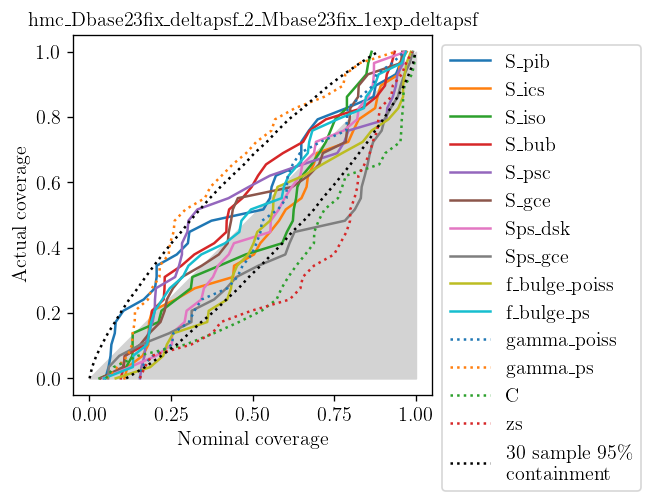

In [6]:
labels = [
    'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_psc', 'S_gce',
    'Sps_dsk', 'Sps_gce',
    'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
]
# labels = [
#     'Sps_gce','gamma_ps',
# ]
# labels = [
#     'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_blg', 'S_nfw', 'Sps_nfw', 'Sps_blg', 'Sps_dsk',
#     'gamma_poiss', 'gamma_ps', 'C', 'zs'
# ]
# z['S_gce'] = ([0,0.5], [0.5, 1])
# z['f_bulge_poiss'] = ([0,0.6], [0.6, 1])
probs = [z[k] for k in labels]
ls_s = ['-'] * 10 + [':'] * 10

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
if labels is None:
    labels = [None for _ in probs]
for prob, label, ls in zip(probs, labels, ls_s):
    ax.plot(prob[0], prob[1], label=label, ls=ls)

n_run = len(probs[0][0])
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Nominal coverage', ylabel='Actual coverage', title=run_name)

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()
# plt.savefig('tmp.pdf')

# Corner

In [5]:
! ls -lt ../outputs/fit/svi_Dsim_truth_n30_Mnp_0327

total 24936
-rw-r--r--. 1 yitians iaifi_lab 18403556 Mar 27 21:56 svi_samples_i0_n50000_ns5000.p
-rw-r--r--. 1 yitians iaifi_lab  1843349 Mar 27 21:09 svi_samples_i0_n5000_ns500.p


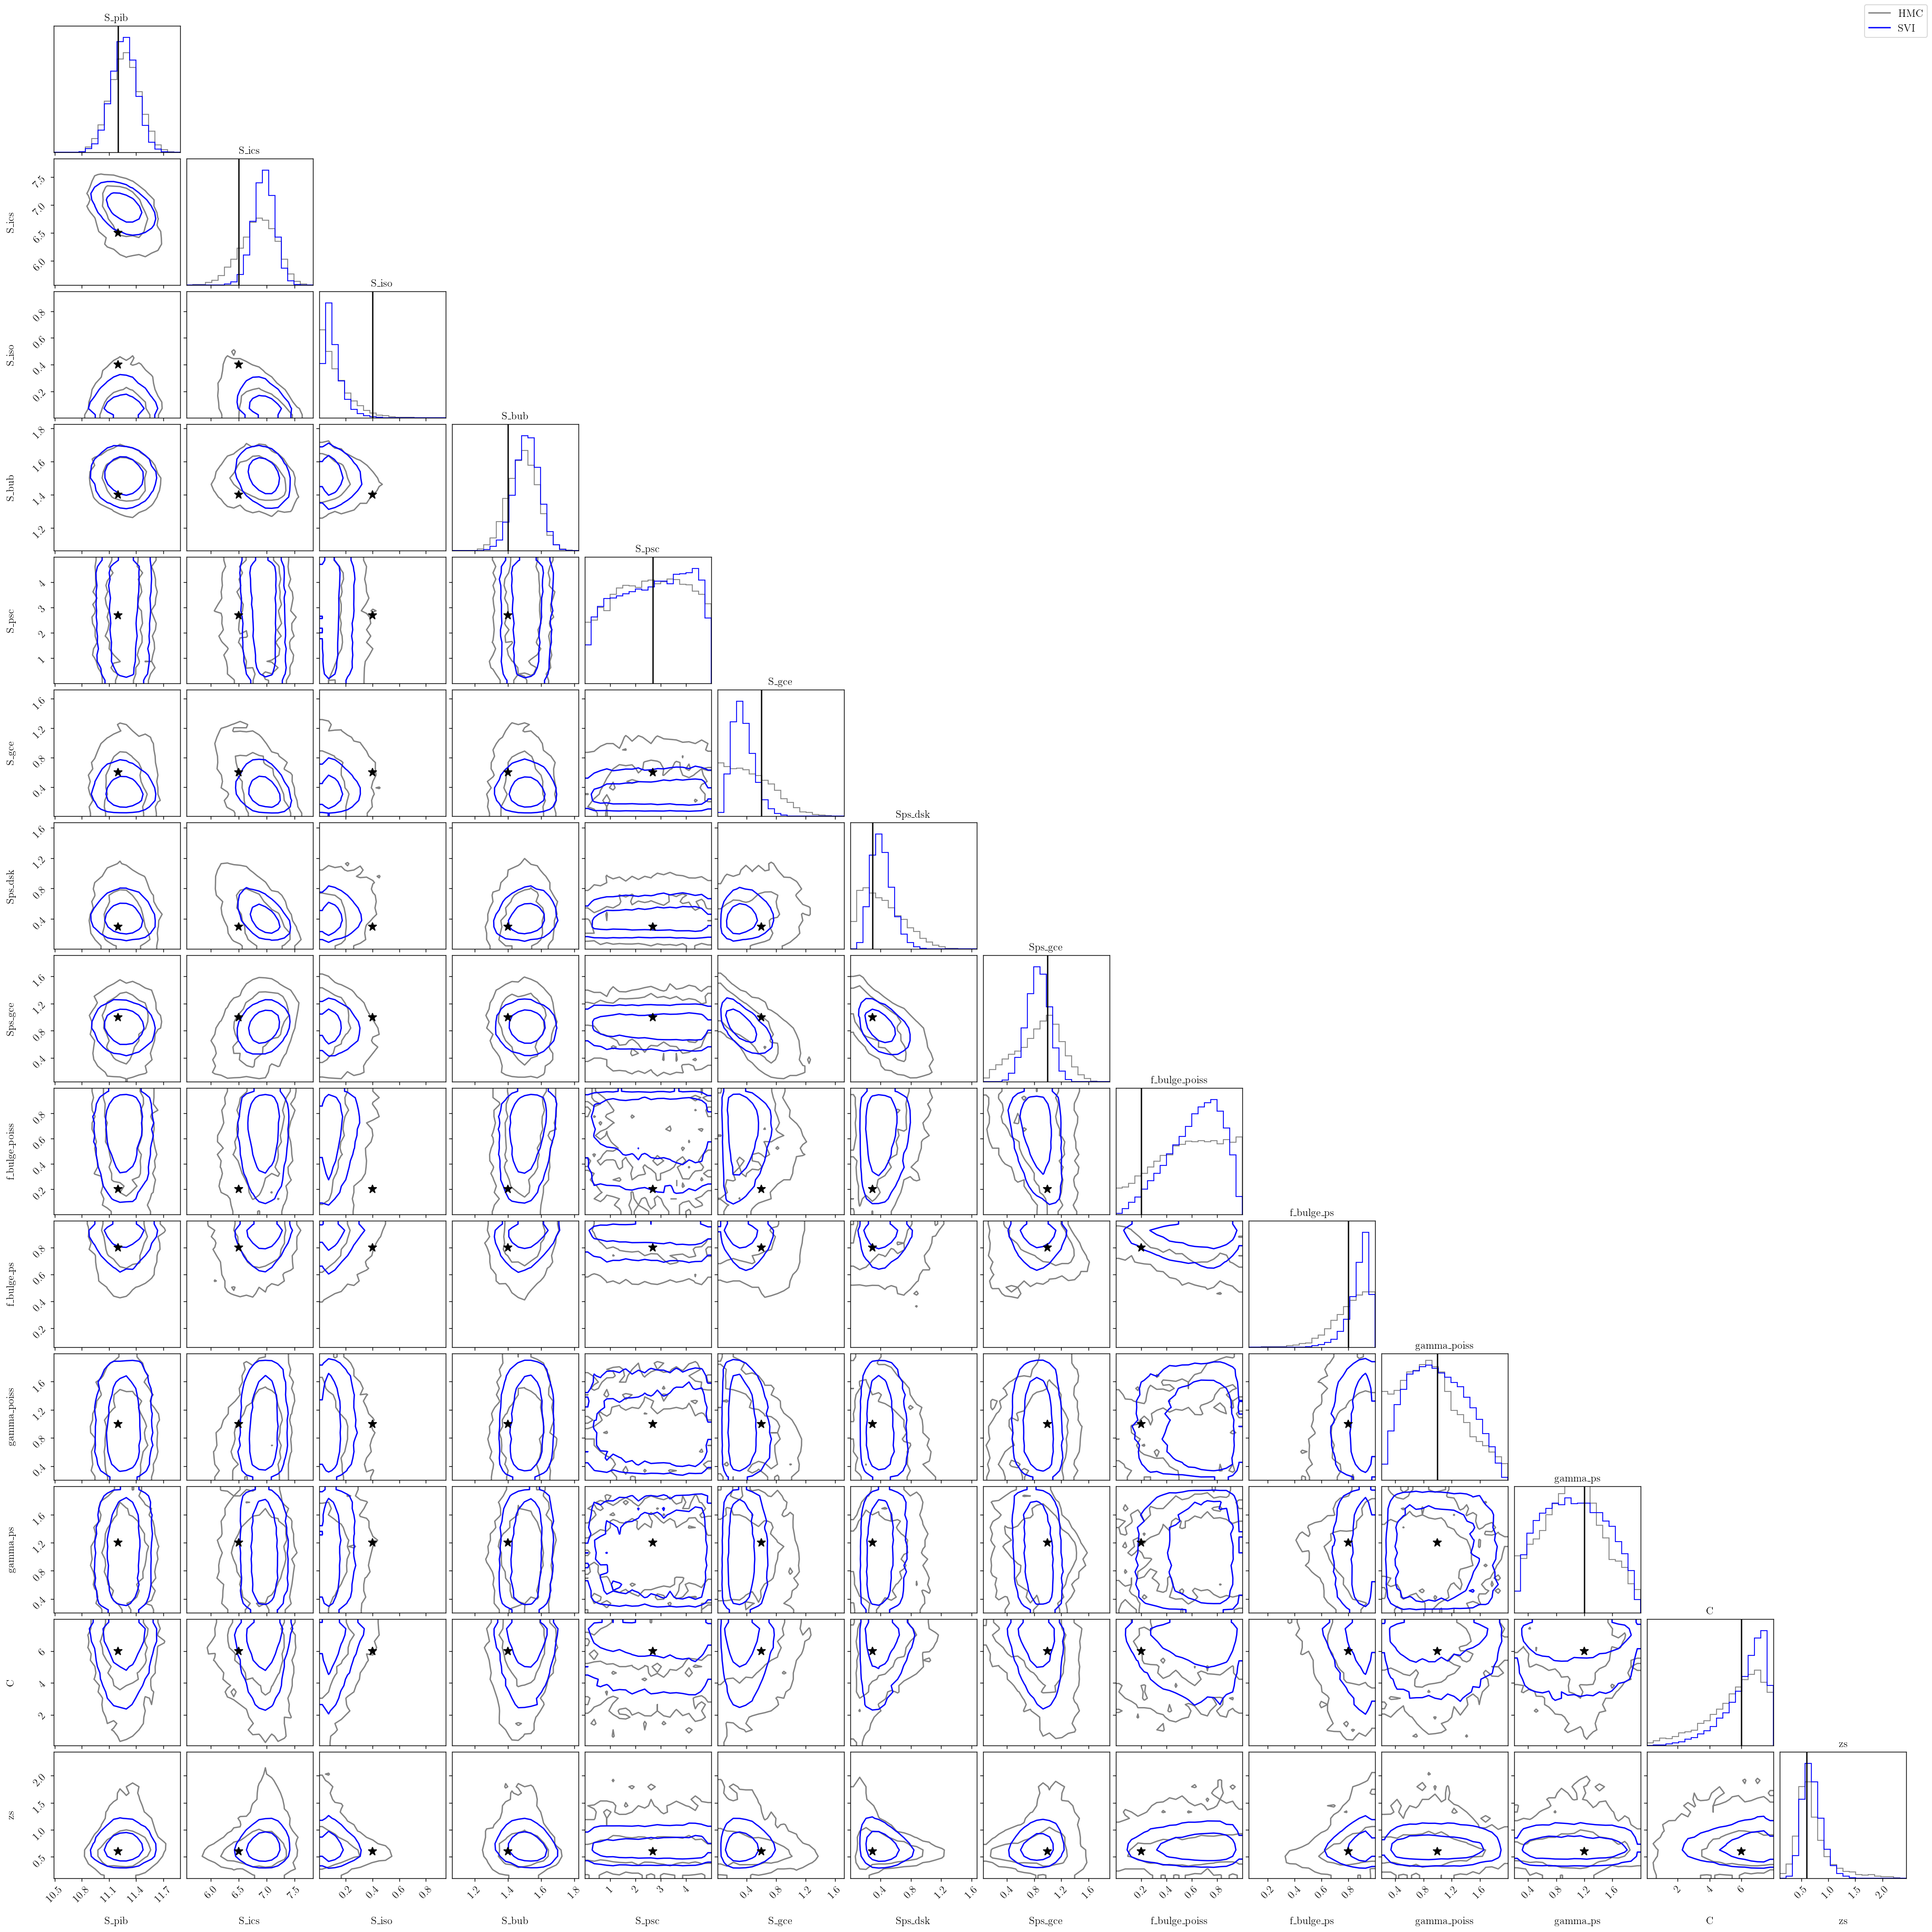

In [7]:
labels = [
    'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_psc', 'S_gce', 'Sps_dsk', 'Sps_gce',
    'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
]
# labels = [
#     'Sps_gce','gamma_ps', 'sb1_gce', 'n2_gce'
# ]
s_in = {}
labels_dict = {}
colors_dict = {}

nskey = 'HMC'
s = pickle.load(open(f'../outputs/fit/hmc_Dsim_truth_n30_Mnp_0327/hmc_samples_i0_n10000_ns0.p', 'rb'))
s_in[nskey] = {k: s[k] for k in labels}
labels_dict[nskey] = nskey
colors_dict[nskey] = 'gray'

nskey = 'SVI'
s = pickle.load(open(f'../outputs/fit/svi_Dsim_truth_n30_Mnp_0327/svi_samples_i0_n50000_ns5000.p', 'rb'))
s_in[nskey] = {k: s[k] for k in labels}
labels_dict[nskey] = nskey
colors_dict[nskey] = 'b'

# nskey = 'SVI lr1e-3 ns20k nfn256'
# s = pickle.load(open(f'../outputs/fit/svi_Dbase23fix_deltapsf_2_Mbase23fix_7exp_deltapsf_lr1e-3_ns20k_nfn256/i0_n50000_ns20000.p', 'rb'))
# s_in[nskey] = {k: s[k] for k in labels}
# labels_dict[nskey] = nskey
# colors_dict[nskey] = 'g'

# nskey = 'SVI lr1e-3 ns20k'
# s = pickle.load(open(f'../outputs/fit/svi_Dbase23fix_deltapsf_2_Mbase23fix_7exp_deltapsf_lr1e-3_ns20k/i0_n50000_ns20000.p', 'rb'))
# s_in[nskey] = {k: s[k] for k in labels}
# labels_dict[nskey] = nskey
# colors_dict[nskey] = 'r'

truth_dict = json.load(open('truth_dicts/truth_dict.json', 'r'))
t_in = {k: truth_dict[k] for k in labels}

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict)

# Marginal posterior

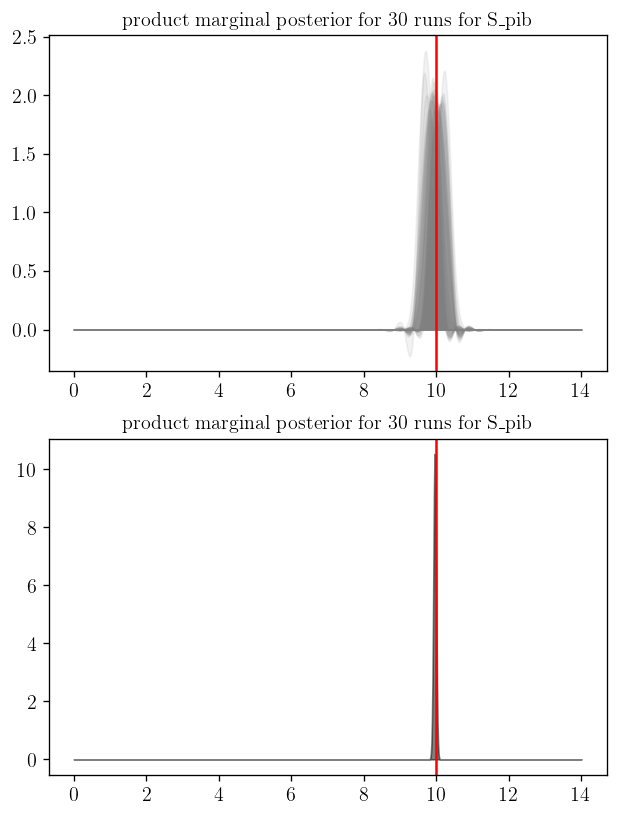

In [11]:
run_name = 'pthmc_Dbase23fix_deltapsf_Mbase23fix_deltapsf'
# run_name = 'hmc_Dbase230927new_Mbase230927'

truth_dict = json.load(open(f'truth_dict_base230927.json', 'r'))
k = 'S_pib'
n_run = 30

prior_dict = json.load(open(f'prior_dict_base230927.json', 'r'))
n_bins = 50
n_bins_sr = 1000
bin_edges = np.linspace(*prior_dict[k], n_bins+1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_centers_sr = np.linspace(*prior_dict[k], n_bins_sr)

fig, axs = plt.subplots(2, 1, figsize=(6, 8))

pdf_tot = np.ones(n_bins_sr)
for i, x in enumerate(range(n_run)):
    s = pickle.load(open(f'../outputs/fit/{run_name}/i{x}_n10000_ns2000.p', 'rb'))
    pdf, _ = np.histogram(s[k], bins=bin_edges)
    pdf_sr = interpolate.CubicSpline(bin_centers, pdf, extrapolate=True)(bin_centers_sr)
    pdf_sr /= np.trapz(pdf_sr, bin_centers_sr)
    axs[0].fill_between(bin_centers_sr, pdf_sr, 0, color='gray', alpha=0.1)

    pdf_tot *= pdf_sr
    pdf_tot /= np.trapz(pdf_tot, bin_centers_sr)

axs[1].fill_between(bin_centers_sr, pdf_tot, 0, color='k', alpha=0.5)

axs[0].axvline(truth_dict[k], color='red')
axs[0].set(title=f'product marginal posterior for {n_run} runs for {k}')
axs[1].axvline(truth_dict[k], color='red')
axs[1].set(title=f'product marginal posterior for {n_run} runs for {k}');

# 2D marginal post.

# Data

In [14]:
data_s = np.load('../outputs/sims/sim_s1k_n100.npy')
mask_roi = np.load('mask_roi.npy')
mask_norm = np.load('mask_norm.npy')
data_full = np.zeros((data_s.shape[0], len(mask_roi)))
data_full[:, ~mask_norm] = data_s
data_full[:, mask_roi] = 0

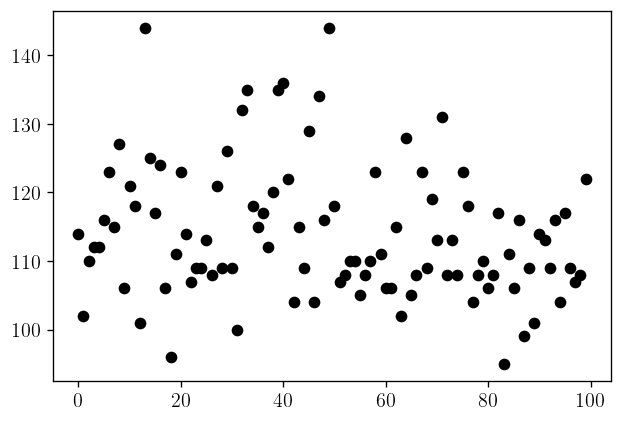

In [15]:
plt.plot(data_full.max(axis=1), 'ko')

# View data

In [2]:
mask_roi = np.load('mask_roi.npy')
mask_norm = np.load('mask_norm.npy')

def plot_data(ax, data, **kwargs):
    if len(data) < mask_norm.shape[0]:
        data_full = np.zeros(mask_norm.shape[0])
        data_full[~mask_norm] = data
    else:
        data_full = data
    plt.sca(ax)
    hp.cartview(data_full, lonra=[-25, 25], latra=[-25, 25], hold=True, **kwargs)

In [10]:
np.any(np.isinf(data1)), np.any(np.isnan(data1))

(False, False)

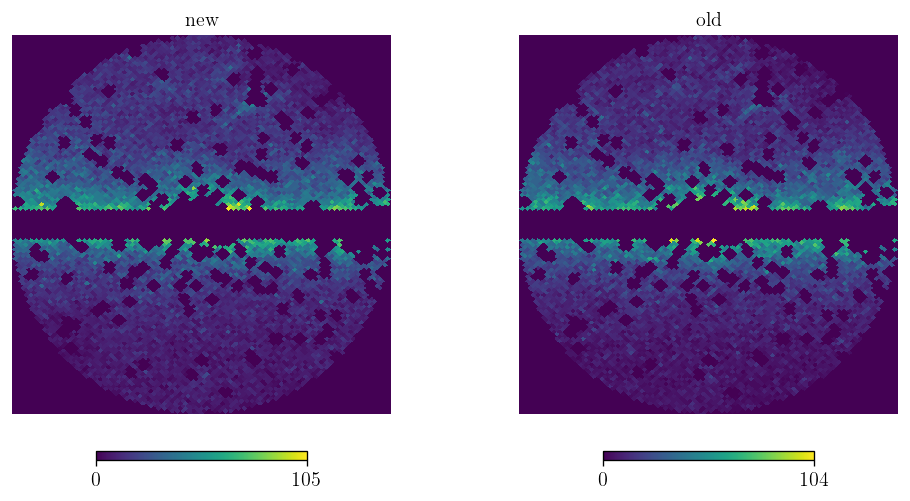

In [5]:
data0 = np.load('../outputs/sims/new_gpsfix_s1k_n100.npy')[0]
data1 = np.load('../outputs/sims/gpsfix_s1k_n100.npy')[1]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_data(axs[0], data0, title='new')
plot_data(axs[1], data1, title='old')

In [ ]:
from models.np_model import NPModel

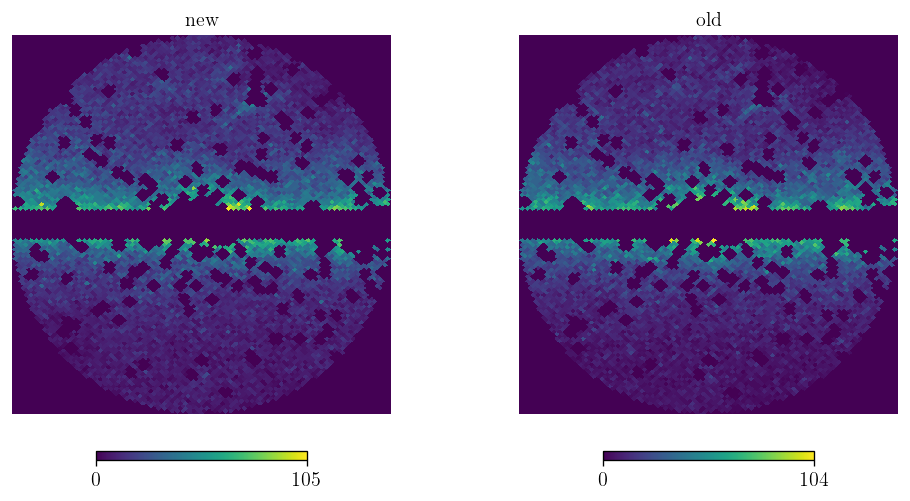

In [ ]:
data0 = np.load('../outputs/sims/new_gpsfix_s1k_n100.npy')[0]
data1 = np.load('../outputs/sims/gpsfix_s1k_n100.npy')[1]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_data(axs[0], data0, title='new')
plot_data(axs[1], data1, title='old')

In [40]:
from models.np_model import NPModel
m = NPModel(data=np.zeros(mask_norm.shape[0]))

Number of pixels in ROI: 6839
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/production/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 0.0


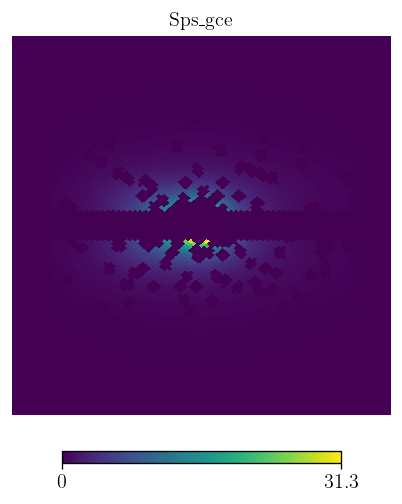

In [58]:
truth_dict = json.load(open('truth_dict_base230927new.json', 'r'))
temp_nfw = m.nfw_template.get_NFW2_template(gamma=truth_dict['gamma_ps'])
temp_nfw /= np.mean(temp_nfw[~mask_norm])
temp_blg = m.bulge_templates[1]
temp_blg /= np.mean(temp_blg[~mask_norm])
f = truth_dict['f_bulge_ps']
temp = f * temp_blg + (1 - f) * temp_nfw

temp = np.array(temp)
temp[mask_roi] = 0

fig, axs = plt.subplots(1, 1, figsize=(6, 5))
plot_data(axs, temp, title='Sps_gce')

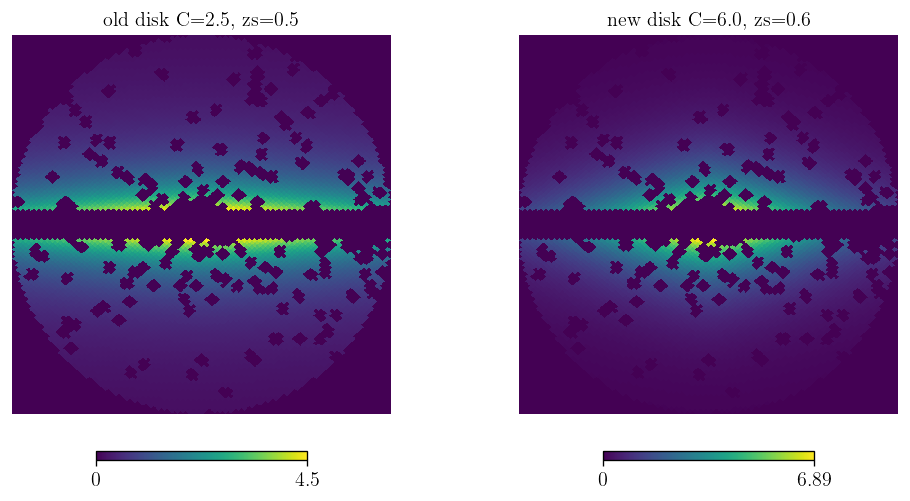

In [46]:
truth_dict = json.load(open('truth_dict_base230927.json', 'r'))
temp_ps_dsk = m.disk_template.get_template(zs=truth_dict['zs'], C=truth_dict['C'])
temp_ps_dsk = np.array(temp_ps_dsk)
temp_ps_dsk /= np.mean(temp_ps_dsk[~mask_norm])

truth_dict2 = json.load(open('truth_dict_base230927new.json', 'r'))
temp_ps_dsk2 = m.disk_template.get_template(zs=truth_dict2['zs'], C=truth_dict2['C'])
temp_ps_dsk2 = np.array(temp_ps_dsk2)
temp_ps_dsk2 /= np.mean(temp_ps_dsk2[~mask_norm])

temp_ps_dsk[mask_roi] = 0
temp_ps_dsk2[mask_roi] = 0

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_data(axs[0], temp_ps_dsk, title=f'old disk C={truth_dict["C"]}, zs={truth_dict["zs"]}')
plot_data(axs[1], temp_ps_dsk2, title=f'new disk C={truth_dict2["C"]}, zs={truth_dict2["zs"]}')

# Compare truth

In [5]:
truth_dict_s = [
    json.load(open('truth_dict_base230927.json', 'r')),
    json.load(open('truth_dict_psc.json', 'r')),
    json.load(open('truth_dict_base230927new.json', 'r'))
]
name_s = ['base', 'psc', 'base_new']
prior_dict = json.load(open('prior_dict_base230927.json', 'r'))

In [14]:
print(f'            '+' '.join([f'{n:>10}' for n in name_s])+'    prior')
for k in truth_dict_s[0].keys():
    if isinstance(truth_dict_s[0][k], list):
        str_s = [f'{str(truth_dict_s[0][k]):>10}' for i in range(len(truth_dict_s))]
    elif k.starts_with('A'):
        continue
    else:
        str_s = [f'{truth_dict_s[i][k]:>10.1f}' for i in range(len(truth_dict_s))]
    print(f'{k:12}'+' '.join(str_s)+    f'    {prior_dict[k]}')

                  base        psc   base_new    prior
theta_pib   [1.0, 0.0, 0.0] [1.0, 0.0, 0.0] [1.0, 0.0, 0.0]    Dirichlet
theta_ics   [1.0, 0.0, 0.0] [1.0, 0.0, 0.0] [1.0, 0.0, 0.0]    Dirichlet


AttributeError: 'str' object has no attribute 'starts_with'

In [15]:
from itertools import cycle

def show_interval_and_values(ax, y, interval, values, normalize=False):
    cc = cycle(plt.rcParams['axes.prop_cycle'])
    if normalize:
        values = [(v - interval[0]) / (interval[1] - interval[0]) for v in values]
        interval = [0, 1]
    interval_style = dict(color='k', lw=2)
    ax.plot(interval, [y, y], **interval_style)
    ax.plot([interval[0], interval[0]], [y-0.1, y+0.1], **interval_style)
    ax.plot([interval[1], interval[1]], [y-0.1, y+0.1], **interval_style)
    for v in values:
        ax.plot(v, y, marker='o', **next(cc))

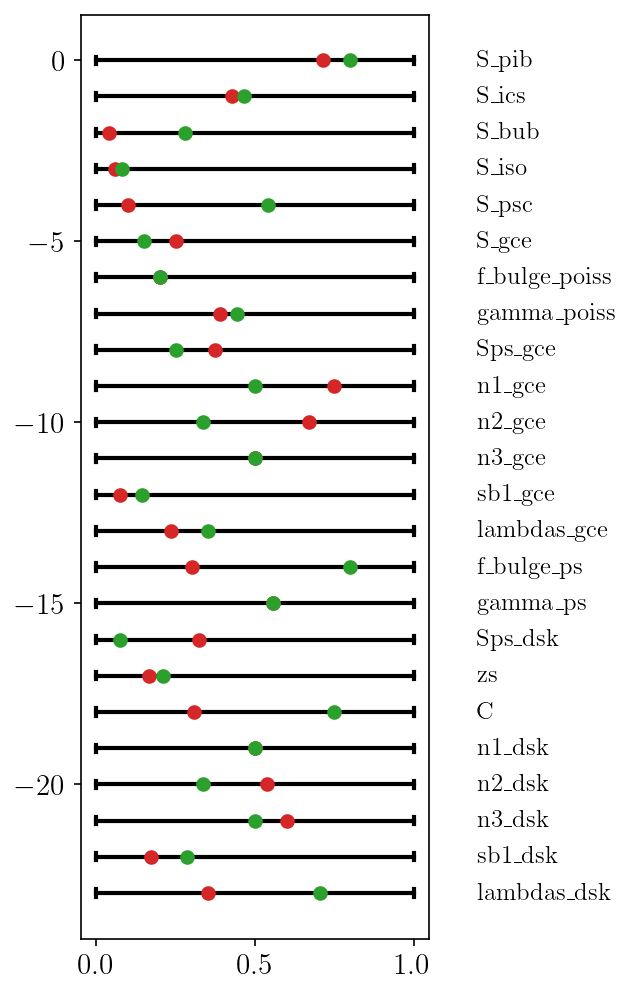

In [20]:
fig, axs = plt.subplots(1, 1, figsize=(3, 8))
ax = axs
y = 0
for k in truth_dict_new.keys():
    if not isinstance(truth_dict_old[k], list):
        show_interval_and_values(ax, y, prior_dict[k], [truth_dict_old[k], truth_dict_new[k]], normalize=True)
        ax.text(1.2, y, k, ha='left', va='center')
        y -= 1

# Compare LL

In [11]:
from models.np_model import NPModel
m = NPModel(data=np.zeros(mask_norm.shape[0]))

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of pixels in ROI: 6839
Using psf: king
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/production/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 0.0


In [24]:
import jax.numpy as jnp
from models.scd import dnds
import jax
from likelihoods.npll_jax import log_like_np
from einops import repeat

In [21]:
def model(self, data, vd):
    
    # Get mixed pib template
    theta_pib = jnp.array(vd['theta_pib'])
    temp_pib = jnp.sum(theta_pib[:, None] * self.pib, 0)

    # Get mixed ics template
    theta_ics = jnp.array(vd['theta_ics'])
    temp_ics = jnp.sum(theta_ics[:, None] * self.ics, 0)

    S_gce = vd['S_gce']
        
    temps = [self.temp_iso, self.temp_bub, self.temp_psc, temp_pib, temp_ics]
    temp_labels = ["iso", "bub", "psc", "pib", "ics"]
            
    mu = jnp.zeros_like(data)
    
    for temp, temp_label in zip(temps, temp_labels):
        
        S_temp = vd["S_{}".format(temp_label)]
        
        if temp_label in ["pib"]:
            
            temp_pib_mod = jnp.zeros_like(data)
            for ii in range(len(self.Ylm_temps)):
                Alm = 0.
                temp_pib_mod += Alm * self.Ylm_temps[ii]
            
            temp_pib_mod = (1. + temp_pib_mod) * temp
            
            A_temp = S_temp / jnp.mean(temp_pib_mod[~self.normalization_mask])
            mu += A_temp * temp_pib_mod  
        else:
            A_temp = S_temp / jnp.mean(temp[~self.normalization_mask])
            mu += A_temp * temp     
                                        
    gamma_ps = vd["gamma_ps"]
    gamma_poiss = vd["gamma_poiss"]

    temp_gce_nfw_ps = self.nfw_template.get_NFW2_template(gamma=gamma_ps) if self.non_poissonian else None
    temp_gce_nfw_poiss = self.nfw_template.get_NFW2_template(gamma=gamma_poiss)
        

    zs = vd["zs"]
    C = vd["C"]
    temp_dsk = self.disk_template.get_template(zs=zs, C=C)
            
    f_bulge_ps = vd["f_bulge_ps"]
    f_bulge_poiss = vd["f_bulge_poiss"]
    
    theta_bulge_poiss = jnp.array(vd["theta_bulge_poiss"])
    temp_bulge = jnp.sum(theta_bulge_poiss[:, None] * self.bulge_templates, 0)
    
    # Normalize to same mean
    A_gce_nfw = S_gce / jnp.mean(temp_gce_nfw_poiss[~self.normalization_mask])
    A_gce_bulge = S_gce / jnp.mean(temp_bulge[~self.normalization_mask])
    temp_gce_poiss = (1 - f_bulge_poiss) * A_gce_nfw * temp_gce_nfw_poiss \
                        + f_bulge_poiss * A_gce_bulge * temp_bulge
    
    A_gce = S_gce / jnp.mean(temp_gce_poiss[~self.normalization_mask])
    mu += A_gce * temp_gce_poiss
    
    if self.non_poissonian:
        # Get mixed bulge template
        theta_bulge_ps = jnp.array(vd["theta_bulge_ps"])
        temp_bulge = jnp.sum(theta_bulge_ps[:, None] * self.bulge_templates, 0)

        # Normalize to same mean
        A_gce_nfw = 1 / jnp.mean(temp_gce_nfw_ps[~self.normalization_mask])
        A_gce_bulge = 1 / jnp.mean(temp_bulge[~self.normalization_mask])

        # Get hybrid template
        temp_gce_ps = (1 - f_bulge_ps) * A_gce_nfw * temp_gce_nfw_ps + f_bulge_ps * A_gce_bulge * temp_bulge

        npt_compressed = jnp.array([temp_gce_ps, temp_dsk])

        theta = []    

        for ips, ps in enumerate(["gce", "dsk"]):

            Sps = vd["Sps_{}".format(ps)]

            n1 = vd["n1_{}".format(ps)]
            n2 = vd["n2_{}".format(ps)]
            n3 = vd["n3_{}".format(ps)]
            sb1 = vd["sb1_{}".format(ps)]
            lambda_s = vd["lambdas_{}".format(ps)]

            theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])

            s_ary = jnp.logspace(-1., 2., 1000)
            dnds_ary = dnds(s_ary, theta_tmp)

            A = Sps / jnp.mean(npt_compressed[ips][~self.normalization_mask] * jnp.trapz(s_ary * dnds_ary, s_ary))

            theta.append([A, n1, n2, n3, sb1, lambda_s * sb1])

        theta = jnp.array(theta)
            
    # Pad the last exposure region so that all are the same size
    exp_lens = [len(self.expreg_indices[i]) for i in range(len(self.expreg_indices))]
    n_pad = exp_lens[0] - exp_lens[-1]
    
    expreg_indices = jnp.zeros_like(self.expreg_indices)
    expreg_indices = expreg_indices.at[:-1].set(self.expreg_indices[:-1])
    expreg_indices = expreg_indices.at[-1].set(jnp.pad(self.expreg_indices[-1], (0, n_pad)))

    log_like_np_exp_vmapped = jax.vmap(log_like_np, in_axes=(0, 0, 1, 0, None, None, None, None))
            
    # Get relevant arrays for different exposure regions
    mu_batch = mu[~self.mask_roi][jnp.array(expreg_indices)]
    if self.non_poissonian:
        npt_compressed_batch = npt_compressed[:, ~self.mask_roi][:, jnp.array(expreg_indices)]
    data_batch = data[~self.mask_roi][jnp.array(expreg_indices)]
    
    exposure_multiplier = self.exposure_means_list / self.exposure_mean
    
    # Scale non-Poissonian parameters (norm divided by exposure ratio, breaks multiplied)
    if self.non_poissonian:
        theta = repeat(theta, "n_ps n_param -> n_exp n_ps n_param", n_exp=len(expreg_indices))
        theta = theta.at[:, :, 0].set(theta[:, :, 0] / exposure_multiplier[:, None])
        theta = theta.at[:, :, -1].set(theta[:, :, -1] * exposure_multiplier[:, None])
        theta = theta.at[:, :, -2].set(theta[:, :, -2] * exposure_multiplier[:, None])
    
    log_like_exp = log_like_np_exp_vmapped(theta, mu_batch, npt_compressed_batch, data_batch, self.f_ary, self.df_rho_ary, self.k_max, len(expreg_indices[0]))
    log_like = jnp.sum(log_like_exp)
    return log_like

In [53]:
vd = json.load(open('truth_dict_base230927.json', 'r'))
data = jnp.array(np.load('../outputs/sims/gpsfix_s1k_n100.npy'), dtype=jnp.int32)

In [54]:
a0 = []
vd = json.load(open('truth_dict_base230927.json', 'r'))
for i in range(30):
    m.k_max = int(jnp.max(data[i]))
    a0.append(model(m, data[i], vd))

In [55]:
a1 = []
vd['C'] = 3.870763450
for i in range(30):
    m.k_max = int(jnp.max(data[i]))
    a1.append(model(m, data[i], vd))

In [56]:
for i in range(30):
    print(a0[i], a1[i], a0[i] - a1[i])

-19843.637537150436 -19846.264351272817 2.6268141223808925
-19650.597644330686 -19651.65761113611 1.0599668054237554
-19860.243499191456 -19865.52415644849 5.280657257033454
-19750.742546351103 -19750.59348502507 -0.14906132603209699
-19762.374111168057 -19765.563272415315 3.189161247257289
-19859.641161732092 -19861.8207103729 2.179548640808207
-19710.993544656925 -19708.641030891344 -2.3525137655815342
-19852.784644681997 -19852.576427725053 -0.20821695694394293
-19848.96276069127 -19856.218207380727 7.25544668945804
-19876.413951559105 -19882.3184395232 5.904487964093278
-19818.74510348549 -19820.29524786496 1.5501443794710212
-19772.16058018559 -19774.20364814697 2.043067961378256
-19854.592420543744 -19859.03740689024 4.444986346494261
-19702.20744072573 -19700.669824074314 -1.5376166514179204
-19710.47911210653 -19704.13134309036 -6.347769016167149
-19826.5426405748 -19829.208793138238 2.6661525634372083
-19757.390431980544 -19761.413397290387 4.02296530984313
-19863.946890273794

In [ ]:
for i in range(30):
    print(a0[i], a1[i], a0[i] - a1[i])

-19843.637537150436 -19853.220846365926 9.583309215489862
-19650.597644330686 -19661.36299001868 10.765345687992522
-19860.243499191456 -19859.60373245788 -0.6397667335768347
-19750.742546351103 -19756.001456338803 5.258909987700463
-19762.374111168057 -19776.540630175565 14.166519007507304
-19859.641161732092 -19863.970370786694 4.329209054601961
-19710.993544656925 -19717.226838077007 6.233293420082191
-19852.784644681997 -19855.741835408633 2.957190726636327
-19848.96276069127 -19865.829132283965 16.86637159269594
-19876.413951559105 -19880.797328102053 4.383376542948099
-19818.74510348549 -19817.428471611158 -1.316631874331506
-19772.16058018559 -19783.032732938667 10.87215275307608
-19854.592420543744 -19861.525181433157 6.932760889412748
-19702.20744072573 -19711.432718776905 9.225278051173518
-19710.47911210653 -19720.26534217719 9.786230070661986
-19826.5426405748 -19827.57414665581 1.0315060810098657
-19757.390431980544 -19764.163620394917 6.773188414372271
-19863.946890273794

In [42]:
s = pickle.load(open(f'../outputs/fit/{run_name}/i0_n10000_ns0.p', 'rb'))
s['theta_bulge_poiss'].shape

(10000, 5)

In [45]:
run_name = 'hmc_Dgpsfix_s1k_Mkmaxfix_s1k'
s = pickle.load(open(f'../outputs/fit/{run_name}/i0_n10000_ns0.p', 'rb'))
mean_dict = {k: [np.mean(s[k], axis=0)] for k in s.keys()}
for i, x in enumerate(range(30)):
    s = pickle.load(open(f'../outputs/fit/{run_name}/i{x}_n10000_ns0.p', 'rb'))
    for k in s.keys():
        mean_dict[k].append(np.mean(s[k], axis=0))
mean_dict = {k: np.mean(v, axis=0) for k, v in mean_dict.items()}
mean_dict

{'Alm_0': 0.0014993741996418767,
 'Alm_1': 0.0017828545217713173,
 'Alm_2': 0.0027355607751966033,
 'Alm_3': 0.00027808695057313803,
 'Alm_4': 0.0006457696269420098,
 'Alm_5': 0.0009113529701641291,
 'C': 3.8707634506063795,
 'S_bub': 0.20406567502000744,
 'S_gce': 0.848365762483275,
 'S_ics': 6.303625085488799,
 'S_iso': 0.36336581309954646,
 'S_pib': 9.939847552252827,
 'S_psc': 1.9738702026442192,
 'Sps_dsk': 1.6729062812315536,
 'Sps_gce': 0.9857193313673714,
 'f_bulge_poiss': 0.3809464312009202,
 'f_bulge_ps': 0.4069512007968499,
 'gamma_poiss': 1.2172260901265983,
 'gamma_ps': 1.2113420671820754,
 'lambdas_dsk': 0.49003728371872357,
 'lambdas_gce': 0.4611669753248206,
 'n1_dsk': 5.099023945383252,
 'n1_gce': 5.098210301409485,
 'n2_dsk': 1.2498883396148124,
 'n2_gce': 1.2826096520414179,
 'n3_dsk': -5.499987635736554,
 'n3_gce': -5.4913560890285975,
 'sb1_dsk': 10.185140208675483,
 'sb1_gce': 11.452580361442715,
 'theta_bulge_poiss': array([0.25956766, 0.26505486, 0.10013265, 0.2

In [35]:
vd

{'theta_pib': [1.0, 0.0, 0.0],
 'theta_ics': [1.0, 0.0, 0.0],
 'S_iso': 0.3,
 'S_bub': 0.2,
 'S_psc': 0.5,
 'S_pib': 10.0,
 'S_ics': 6.0,
 'Sps_dsk': 1.3,
 'zs': 0.5,
 'C': 2.5,
 'S_gce': 1.0,
 'gamma_poiss': 0.9,
 'f_bulge_poiss': 0.2,
 'Sps_gce': 1.5,
 'gamma_ps': 1.2,
 'f_bulge_ps': 0.3,
 'theta_bulge_poiss': [1.0, 0.0, 0.0, 0.0, 0.0],
 'theta_bulge_ps': [0.0, 1.0, 0.0, 0.0, 0.0],
 'n1_dsk': 5.0,
 'n2_dsk': 1.3,
 'n3_dsk': -5.4,
 'sb1_dsk': 11.0,
 'lambdas_dsk': 0.4,
 'n1_gce': 5.5,
 'n2_gce': 1.5,
 'n3_gce': -5.5,
 'sb1_gce': 7.6,
 'lambdas_gce': 0.3,
 'Alm_0': 0.0,
 'Alm_1': 0.0,
 'Alm_2': 0.0,
 'Alm_3': 0.0,
 'Alm_4': 0.0,
 'Alm_5': 0.0}